<div style="text-align:center; font-weight:bold; font-size:34px; margin-top:40px;">
    Notebook 3 — Yield Reduction Factors
</div>

<p style="text-align:center; font-size:20px; color:#444; margin-top:5px;">
    PyAEZ Version 3.0 &nbsp; | &nbsp; 2026
</p>

<hr style="margin-top:25px; margin-bottom:25px;">

<p style="text-align:center; font-size:18px;">
    This module applies crop‑specific yield reduction factors to the maximum attainable yield computed in Module&nbsp;2.  
    It evaluates the constraint effects separately for rainfed and irrigated conditions, using information retrieved directly from the GAEZ appendices, ensuring that all relevant biophysical limitations are incorporated into the final yield estimation.
</p>

<p style="text-align:center; font-size:16px; color:#555;">
    Prepared by <strong>Dario Spiller</strong><br>
    Geospatial Unit — Land and Water Division (NSL)<br>
    Food and Agriculture Organization of the United Nations (FAO HQ)
</p>

<hr style="margin-top:25px; margin-bottom:25px;">

## Importing Libraries

In [2]:
'''import supporting libraries'''
# import pyaez
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import xarray as xr
import pickle
from pathlib import Path

try:
    from osgeo import gdal
except:
    import gdal
import sys

os.environ['PROJ_LIB'] = '/opt/conda/share/proj'
gdal.UseExceptions() 

# --- BOOTSTRAP: add project root to sys.path ---
project_root = Path().resolve().parent       # tutorials → project root
sys.path.append(str(project_root))

from module0 import pre_proc_utilities

In [3]:
# Setting the correct working folder
pre_proc_utilities.set_working_folder()

Notebook directory : D:\Documenti_Lavoro\FAO\Contratto FAO 2025 Sept-Dec\Python-AEZ-FAO\tutorials
Project root set to: D:\Documenti_Lavoro\FAO\Contratto FAO 2025 Sept-Dec\Python-AEZ-FAO


In [4]:
# AEZ library used to construct the object
from pyaez import ClimaticConstraints
from pyaez.UtilitiesCalc import saveRaster

# Load the pickle object defined in Module 0
with open('./data_input/input_module3/clim_con.pkl', 'rb') as f:
    clim_con = pickle.load(f)


Computed rainfed yield for maize using rainfed management


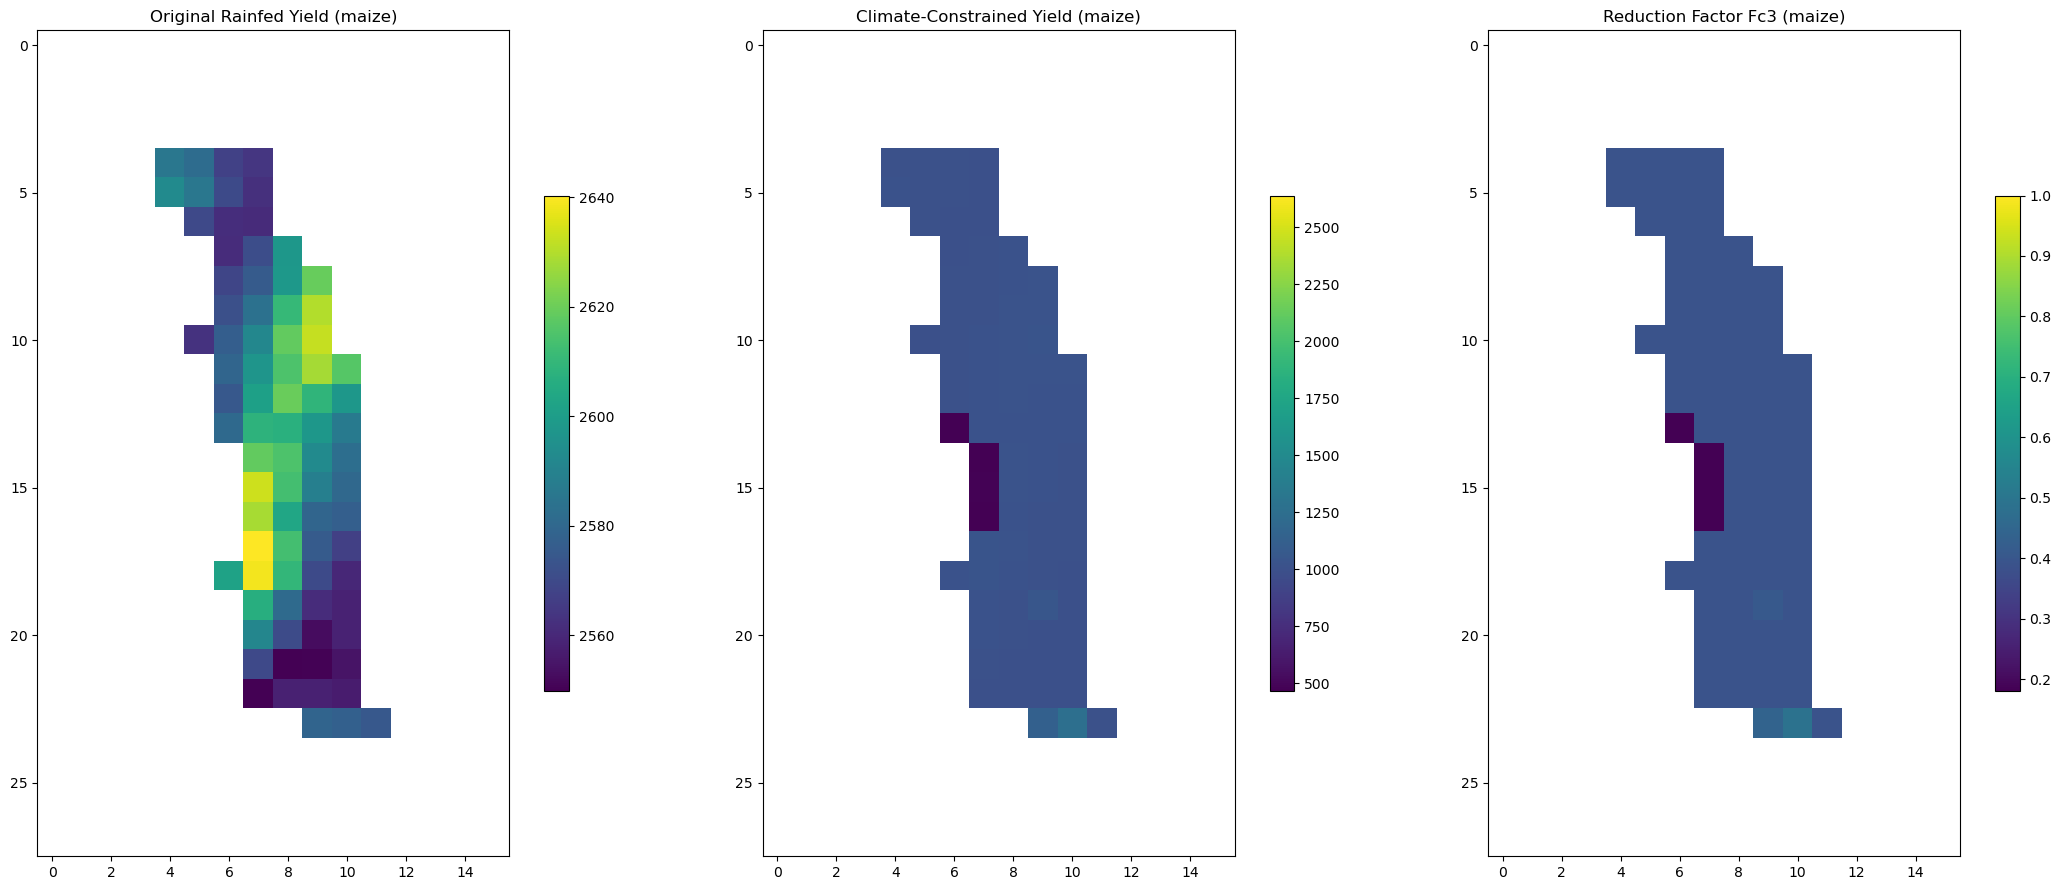

In [5]:
condition_type = 'rainfed'
clim_yield_rain, fc3_rain = clim_con.compute_yield(condition_type, plot_results=True)

Computed irrigated yield for maize using irrigated management


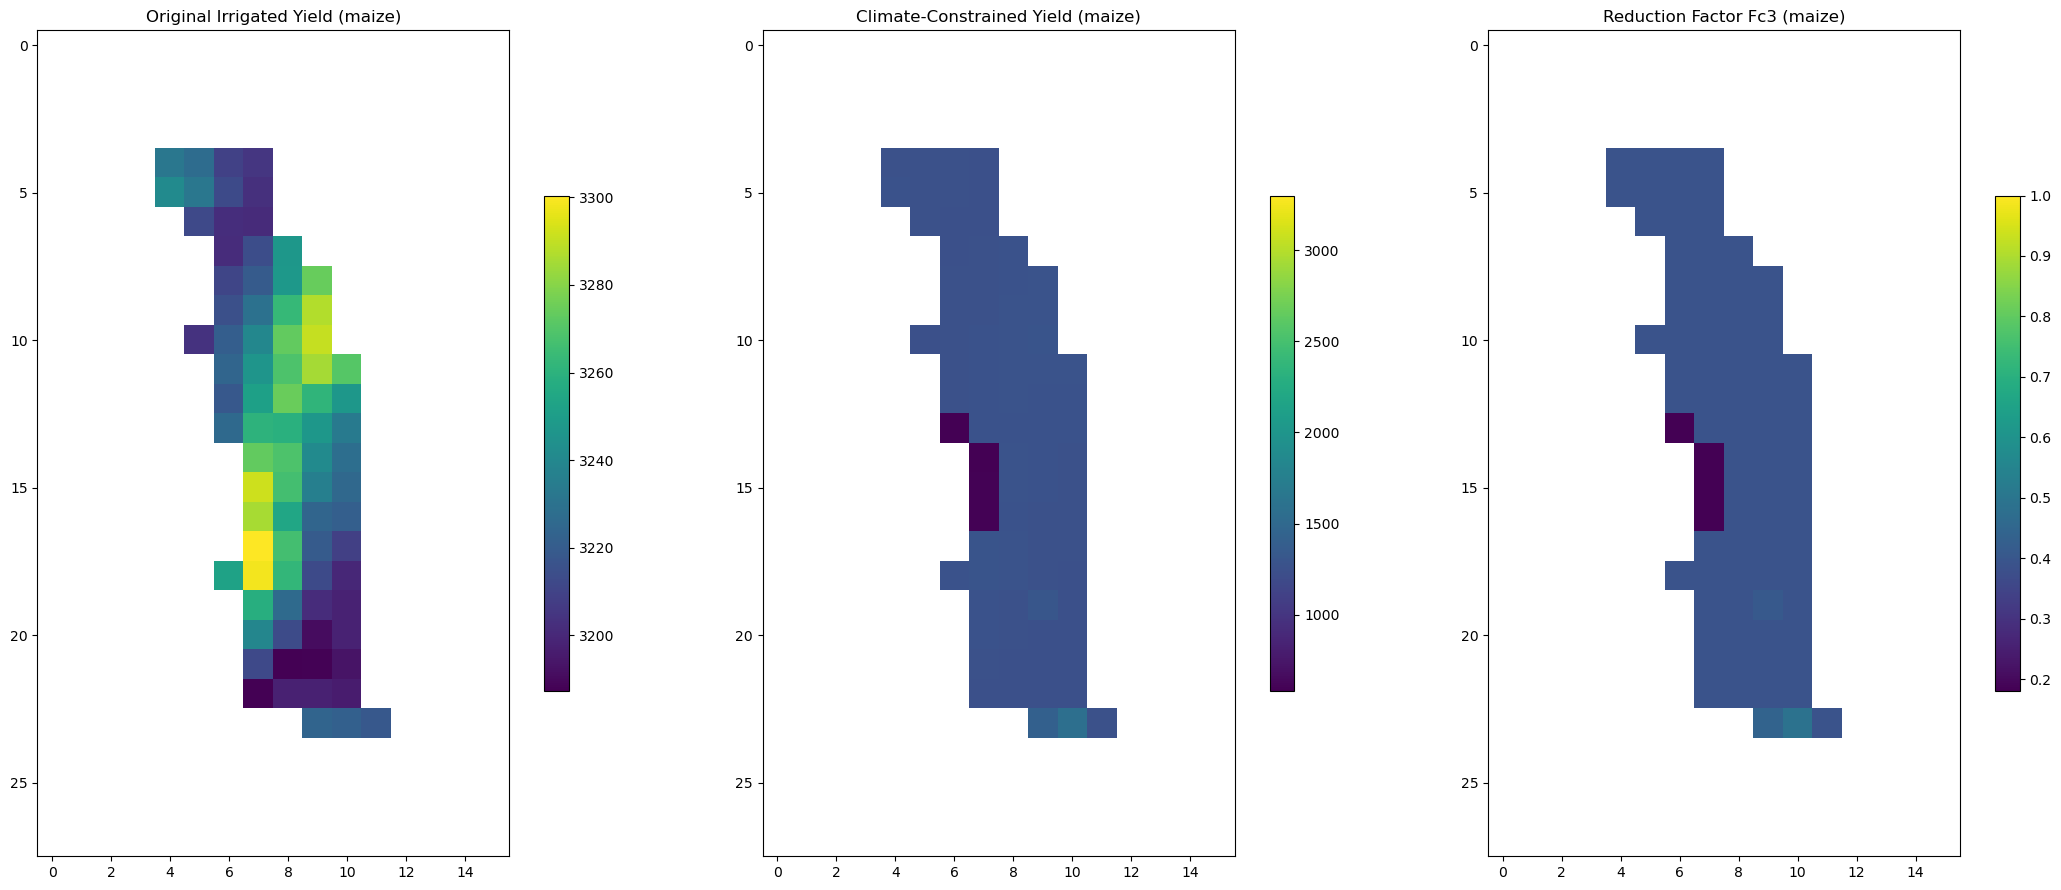

In [6]:
condition_type = 'irrigated'
clim_yield_irr, fc3_irr = clim_con.compute_yield(condition_type, plot_results=True)

In [ ]:
'''save result (Rainfed Condition)'''
saveRaster(mask_path, rf'./data_output/NB3/{clim_con.crop_name}_yld_rain_m3.tif', clim_yield_rain)
saveRaster(mask_path, rf'./data_output/NB3/fc3_{clim_con.crop_name}_rain.tif', fc3_rain)

In [ ]:
'''save result (Irrigated Condition)'''
saveRaster(mask_path, rf'./data_output/NB3/{clim_con.crop_name}_yld_irr_m3.tif', clim_yield_irr)
saveRaster(mask_path, rf'./data_output/NB3/fc3_{clim_con.crop_name}_irr.tif', fc3_irr)
saveRaster(mask_path, r'./data_output/NB3/lgpagc.tif', clim_con.lgp_agc)

<hr>

### END OF MODULE 3: CLIMATIC CONSTRAINTS

<hr>